> ⚠️ **Before Running:** Update the dataset path below to point to your Google Drive folder.
> Dataset: [Download Here](https://drive.google.com/drive/folders/14dp4kEdV9k6esJs0tGTNb3AKFF6d-s9I?usp=sharing)
> Place it in your Google Drive under: `MyDrive/GAN_ART_IMAGES/Images/`

In [1]:
# Step 1: Repo clone (already done, but safe to skip if folder exists)
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 25.03 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix


In [2]:
# Alternative Manual Installation (if Conda fails)
!pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install dominate visdom

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for visdom: filename=visdom-0.2.4-py3-none-any.whl size=1408195 sha256=85a587499c32efae67f5a8d2df3d6bfbc4a9a117d4ad2605549d2738d37618c9
  Stored in directory: /root/.cache/pip/wheels/37/6c/38/64eeaa310e325aacda723e6df1f79ab5e9f31ba195264e04a8
Successfully built visdom


In [3]:
# Step 3: Download pretrained painting models (true GAN adversarial)
!bash ./scripts/download_cyclegan_model.sh style_monet
!bash ./scripts/download_cyclegan_model.sh style_vangogh
!bash ./scripts/download_cyclegan_model.sh style_cezanne
!bash ./scripts/download_cyclegan_model.sh style_ukiyoe

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2025-12-28 11:50:52--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  8.75MB/s    in 12s     

2025-12-28 11:51:05 (3.76 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

Note: 

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [7]:
# Remove any old/incompatible checkpoint
!rm -rf ./checkpoints/style_cezanne_pretrained

# Download the official Cézanne style model
!bash ./scripts/download_cyclegan_model.sh style_cezanne

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_cezanne]
for details.

--2025-12-28 11:55:19--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_cezanne.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_cezanne_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  8.53MB/s    in 8.8s    

2025-12-28 11:55:28 (4.92 MB/s) - ‘./checkpoints/style_cezanne_pretrained/latest_net_G.pth’ saved [45575747/45575747]

In [8]:
!mkdir -p ./checkpoints/style_cezanne_pretrained
!wget http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_cezanne.pth -O ./checkpoints/style_cezanne_pretrained/latest_net_G.pth

--2025-12-28 11:55:32--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_cezanne.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_cezanne_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  5.97MB/s    in 9.9s    

2025-12-28 11:55:42 (4.40 MB/s) - ‘./checkpoints/style_cezanne_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [10]:
!python test.py \
  --dataroot /content/drive/MyDrive/GAN_ART_IMAGES/GAN_ART_IMAGES/Images \
  --model test \
  --dataset_mode single \
  --name style_cezanne_pretrained \
  --netG resnet_9blocks \
  --norm instance \
  --no_dropout \
  --phase test \
  --preprocess none \
  --load_size 256 \
  --crop_size 256 \
  --num_test 50

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/drive/MyDrive/GAN_ART_IMAGES/GAN_ART_IMAGES/Images	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
              

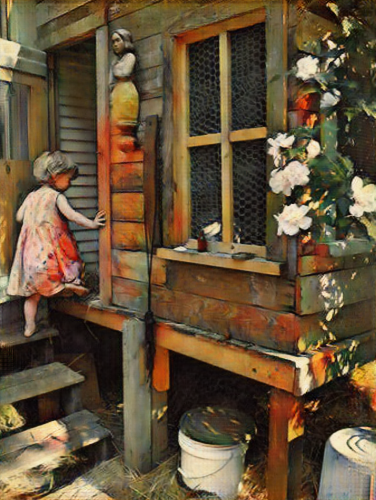

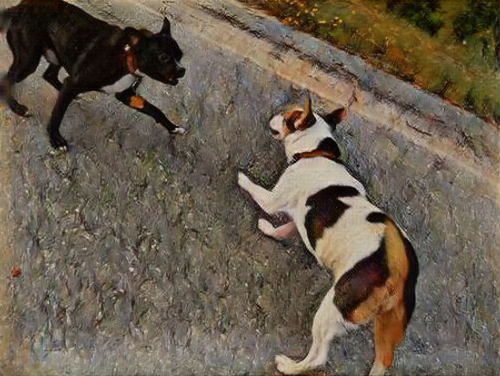

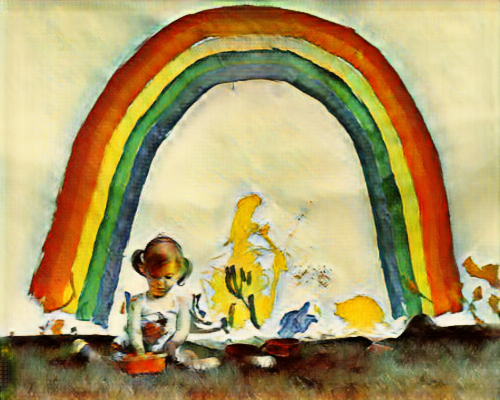

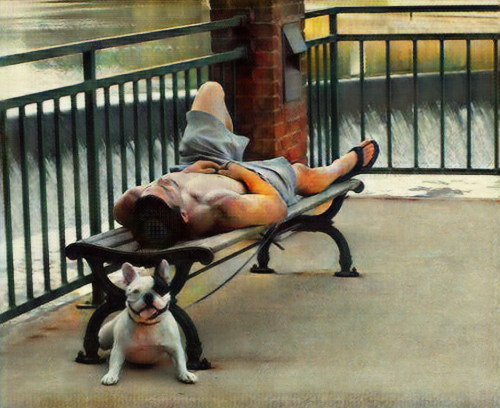

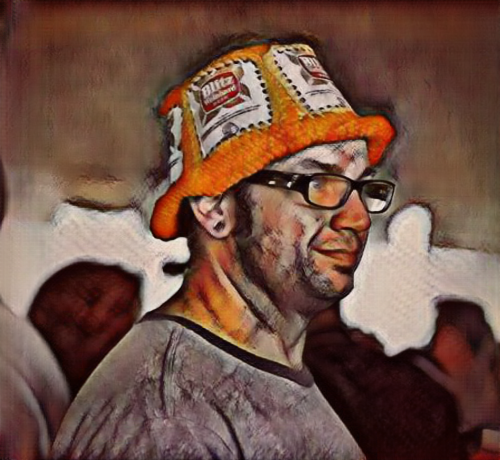

In [11]:
from IPython.display import Image, display
import os
results_dir = './results/style_cezanne_pretrained/test_latest/images/'
fake_images = sorted([f for f in os.listdir(results_dir) if f.endswith('_fake.png')])
for img in fake_images[:5]:  # Show first 5 styled results
    display(Image(os.path.join(results_dir, img)))